In [13]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).





**Pipeline:** Load data → Naive baseline → VADER sentiment → Feature engineering → Feature selection → Train model → Evaluate

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.feature_selection import mutual_info_classif, chi2, RFECV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.utils import resample

In [15]:
df = pd.read_csv('/content/drive/MyDrive/Final_News_Credibility/uk_political_events.csv')
print("Dataset shape:", df.shape)
print("\nTarget distribution:")
print(df['source_correct'].value_counts())
print("\nEvent categories:")
print(df['event_category'].value_counts())

Dataset shape: (264, 18)

Target distribution:
source_correct
PARTIAL    118
TRUE        99
FALSE       47
Name: count, dtype: int64

Event categories:
event_category
Election_Leadership    72
Scandal                66
Resignation            54
Economic_Policy        30
Legal_Courts           24
Vote_Confidence        18
Name: count, dtype: int64


---
## Step 1 - Naive Baseline
Before building anything smart, we check: what score would we get if we just guessed
the most common answer every time, without looking at any clues at all?

Any real model has to beat this score, or it isn't actually learning anything.

In [16]:
# The naive baseline uses no features - it always predicts the most frequent class.
# We use a placeholder X because train_test_split requires both X and y.
# stratify=y ensures class proportions are preserved across train and test splits.

y_raw = df['source_correct']
X_dummy = pd.DataFrame({'placeholder': range(len(df))})

X_tr, X_te, y_tr, y_te = train_test_split(
    X_dummy, y_raw, test_size=0.3, random_state=42, stratify=y_raw
)

baseline = DummyClassifier(strategy='most_frequent')
baseline.fit(X_tr, y_tr)

baseline_acc = accuracy_score(y_te, baseline.predict(X_te))
print("naive baseline accuracy:", round(baseline_acc, 3))

naive baseline accuracy: 0.45


**Finding:** Just guessing "PARTIAL" every time gets about **45%** right, because PARTIAL
is the most common answer in our data. This is our floor - any real model has to beat 45%
to prove it's doing something useful

--
## Step 2 - VADER Sentiment Extraction
VADER (Valence Aware Dictionary and Sentiment Reasoner) reads each article summary and
returns sentiment scores. We test whether the emotional tone of an article predicts its accuracy.

In [17]:
!pip install vaderSentiment -q

# Does writing tone predict accuracy?

In [18]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

def get_vader_scores(text):
    scores = analyzer.polarity_scores(text)
    # compound = overall tone (-1 very negative, +1 very positive)
    # pos / neg / neu = how much of the text is positive / negative / neutral wording
    return scores['compound'], scores['pos'], scores['neg'], scores['neu']

df[['vader_compound', 'vader_pos', 'vader_neg', 'vader_neu']] = df['article_headline'].apply(
    lambda x: pd.Series(get_vader_scores(x))
)

print("Added sentiment scores. New shape:", df.shape)

Added sentiment scores. New shape: (264, 22)


In [19]:
print("Sentiment score ranges across all articles:")
print(df[['vader_compound', 'vader_pos', 'vader_neg']].describe().round(3))

Sentiment score ranges across all articles:
       vader_compound  vader_pos  vader_neg
count         264.000    264.000    264.000
mean           -0.056      0.109      0.139
std             0.419      0.140      0.145
min            -0.778      0.000      0.000
25%            -0.362      0.000      0.000
50%             0.000      0.000      0.141
75%             0.250      0.200      0.252
max             0.908      0.608      0.512


In [20]:
print("Average tone score, grouped by TRUE / PARTIAL / FALSE:")
print(df.groupby('source_correct')['vader_compound'].mean().round(3))

Average tone score, grouped by TRUE / PARTIAL / FALSE:
source_correct
FALSE      0.085
PARTIAL   -0.060
TRUE      -0.117
Name: vader_compound, dtype: float64


# turning everything into numbers

In [21]:
#working on a copy
# df stays intact with all original columns including article_summary.
df_model = df.copy()

df_model = df_model.drop(columns=[
    'article_summary',        # text , already used for VADER extraction
    'article_headline',       # text , not suitable as a numeric feature
    'event_description',      # text , not suitable as a numeric feature
    'outcome',                # future information - using this would be cheating
    'outcome_binary',         # future information - tells us what happened
    'event_name',             # identifier, not a signal
    'event_id',               # identifier, not a signal
    'event_date',             # date metadata, not a credibility signal
    'article_date',           # date metadata  #analyse later
    'initial_coverage_date',  # date metadata
    'outcome_confirmed_by',   # metadata
    'experimental_plan_note', # metadata
    'vader_neu'               # near-constant at ~85% across all rows — pure noise
])

print("Columns left:", df_model.columns.tolist())

Columns left: ['resolution_time_hours', 'event_category', 'source_name', 'framing_prediction', 'source_correct', 'paywall_note', 'vader_compound', 'vader_pos', 'vader_neg']


In [22]:
# Turn the answer into numbers: FALSE=0, PARTIAL=1, TRUE=2
target_map = {'FALSE': 0, 'PARTIAL': 1, 'TRUE': 2}
df_model['source_correct_encoded'] = df_model['source_correct'].map(target_map)

print(df_model[['source_correct', 'source_correct_encoded']].drop_duplicates())

   source_correct  source_correct_encoded
0            TRUE                       2
1         PARTIAL                       1
24          FALSE                       0


In [23]:
# Split into X (the clues) and y (the answer we want to predict)

y = df_model['source_correct_encoded']

X = df_model.drop(columns=[
    'source_correct',
    'source_correct_encoded',
    'framing_prediction',   # missing for a lot of older events
    'paywall_note'          # just a free-text note, not a clean number
])

print("X shape:", X.shape)
print("Clue columns:", X.columns.tolist())

X shape: (264, 6)
Clue columns: ['resolution_time_hours', 'event_category', 'source_name', 'vader_compound', 'vader_pos', 'vader_neg']


In [27]:
# Put every number on the same scale (mean 0, spread 1).
# Without this, a big number like resolution_time_hours could unfairly
# drown out a small number like a sentiment score.

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

print("Scaling done.")

Scaling done.


In [28]:
# Set aside 30% of the data as a test set the model is never allowed to peek at
# until Step 10. stratify=y keeps the same mix of TRUE/PARTIAL/FALSE in both parts.

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("Training rows:", X_train.shape[0])
print("Test rows    :", X_test.shape[0])

Training rows: 184
Test rows    : 80


#Which feature actually matter?

#checking every features on 4 different test of feature selection method. Every test in this step only looks at the training data. The test set stays sealed away.

#test 1 = Mutual information (MI)

Theory: "if i know this feature. clue , does it reduce my confusion about the answer? "A score of 0 means the clue tells us nothing at all.

In [29]:
mi_scores = mutual_info_classif(X_train, y_train, random_state=42)

mi_df = pd.DataFrame({
    'feature': X_train.columns,
    'mutual_information': mi_scores
}).sort_values('mutual_information', ascending=False).round(4)

print(mi_df.to_string(index=False))

                           feature  mutual_information
                 source_name_Times              0.1530
                   source_name_BBC              0.1237
event_category_Election_Leadership              0.0846
    event_category_Vote_Confidence              0.0822
               source_name_Reuters              0.0714
             resolution_time_hours              0.0532
            event_category_Scandal              0.0453
                         vader_pos              0.0330
    event_category_Economic_Policy              0.0240
              source_name_Sky News              0.0014
                    vader_compound              0.0000
                         vader_neg              0.0000
              source_name_Guardian              0.0000
             source_name_Telegraph              0.0000
        event_category_Resignation              0.0000
       event_category_Legal_Courts              0.0000


Finding: Anything scoring below 0.01 is bascially noise.Vader compound, vader negative, and couple of source name and event category stand out as clueless

# **test 2- chi square**
### Theory= is the link between this clue and the answer real, or could it just be luck? "A p-value under 0.05 means the link is probably real, not a coincidence.
###for example: If source_name_BBC and source_correct are independent, then seeing BBC tells  nothing about accuracy

In [30]:
# Chi-square needs positive numbers only, so we rescale everything to 0-1 first.
X_positive = MinMaxScaler().fit_transform(X_train)
chi_scores, chi_pvalues = chi2(X_positive, y_train)

chi_df = pd.DataFrame({
    'feature': X_train.columns,
    'chi2_score': chi_scores,
    'p_value': chi_pvalues
}).sort_values('chi2_score', ascending=False).round(4)

print(chi_df.to_string(index=False))

                           feature  chi2_score  p_value
                   source_name_BBC     42.2927   0.0000
                 source_name_Times     24.5171   0.0000
               source_name_Reuters     20.8312   0.0000
              source_name_Guardian     10.9879   0.0041
    event_category_Economic_Policy      8.7396   0.0127
event_category_Election_Leadership      6.4565   0.0396
             resolution_time_hours      5.2141   0.0738
             source_name_Telegraph      3.2359   0.1983
    event_category_Vote_Confidence      3.1408   0.2080
            event_category_Scandal      2.5612   0.2779
              source_name_Sky News      2.3894   0.3028
                         vader_neg      1.5752   0.4549
       event_category_Legal_Courts      1.0149   0.6020
        event_category_Resignation      0.6027   0.7398
                    vader_compound      0.4300   0.8066
                         vader_pos      0.2444   0.8850


Finding: The same outlets that scored well in test 1 also come back with very small p-vlues here, Two different tests agreeing makes us more confident these are real clues.

## Merge MI and chi-square into one table

In [31]:
# Put Test 1 and Test 2 side by side so they're easy to compare
combined_df = mi_df.merge(chi_df, on='feature')
combined_df['chi2_significant'] = combined_df['p_value'].apply(
    lambda p: 'YES' if p < 0.05 else 'NO'
)
combined_df = combined_df.sort_values('mutual_information', ascending=False).reset_index(drop=True)

print(combined_df[['feature', 'mutual_information', 'chi2_score', 'p_value', 'chi2_significant']].to_string(index=False))

                           feature  mutual_information  chi2_score  p_value chi2_significant
                 source_name_Times              0.1530     24.5171   0.0000              YES
                   source_name_BBC              0.1237     42.2927   0.0000              YES
event_category_Election_Leadership              0.0846      6.4565   0.0396              YES
    event_category_Vote_Confidence              0.0822      3.1408   0.2080               NO
               source_name_Reuters              0.0714     20.8312   0.0000              YES
             resolution_time_hours              0.0532      5.2141   0.0738               NO
            event_category_Scandal              0.0453      2.5612   0.2779               NO
                         vader_pos              0.0330      0.2444   0.8850               NO
    event_category_Economic_Policy              0.0240      8.7396   0.0127              YES
              source_name_Sky News              0.0014      2.3894   0

# wrapper method

## test 3-  RFECV (Recursive Feature Elimination with Cross-Validation)

theory: the train it over and over methos. this method actually trains the real model again and again , removing the weakest clue each time, to see how few clues we really need.

In [32]:
rfe_base_model = LogisticRegression(
    penalty='l2', C=1.0, solver='lbfgs',
    random_state=42, max_iter=1000
)

rfecv = RFECV(
    estimator=rfe_base_model,
    step=1,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='accuracy',
    min_features_to_select=3
)
rfecv.fit(X_train, y_train)

rfe_selected = [f for f, s in zip(X_train.columns, rfecv.support_) if s]

print("Best number of clues to keep:", rfecv.n_features_)
print("Best CV accuracy found      :", round(rfecv.cv_results_['mean_test_score'].max(), 3))
print()
print("Clues RFECV kept:")
for f in rfe_selected:
    print(" -", f)

Best number of clues to keep: 6
Best CV accuracy found      : 0.756

Clues RFECV kept:
 - resolution_time_hours
 - source_name_BBC
 - source_name_Reuters
 - source_name_Times
 - event_category_Economic_Policy
 - event_category_Election_Leadership


findings- RFECV chose 10 features, CV accuracy 0.748. It kept vader_compound and resolution_time_hours which MI scored zero - these features help the model in combination even though they carry little information individually.

test 4= L1 (lasso)

Theory:This test trains a model that is allowed to completely zero out any clue if thinks is useless.

In [33]:
l1_model = LogisticRegression(
    penalty='l1', C=1.0, solver='liblinear',
    random_state=42, max_iter=1000
)
l1_model.fit(X_train, y_train)

mean_abs_coef = np.mean(np.abs(l1_model.coef_), axis=0)

l1_df = pd.DataFrame({
    'feature': X_train.columns,
    'mean_abs_coefficient': mean_abs_coef.round(4)
}).sort_values('mean_abs_coefficient', ascending=False).reset_index(drop=True)

l1_df['l1_kept'] = l1_df['mean_abs_coefficient'].apply(lambda c: 'YES' if c > 0.001 else 'ZEROED')

l1_kept = l1_df[l1_df['l1_kept'] == 'YES']['feature'].tolist()

print(l1_df.to_string(index=False))

                           feature  mean_abs_coefficient l1_kept
                   source_name_BBC                1.7750     YES
               source_name_Reuters                0.9717     YES
    event_category_Economic_Policy                0.7228     YES
             resolution_time_hours                0.6548     YES
                 source_name_Times                0.5553     YES
event_category_Election_Leadership                0.4639     YES
              source_name_Guardian                0.2587     YES
    event_category_Vote_Confidence                0.1145     YES
                         vader_neg                0.0807     YES
        event_category_Resignation                0.0694     YES
              source_name_Sky News                0.0634     YES
            event_category_Scandal                0.0589     YES
             source_name_Telegraph                0.0444     YES
                         vader_pos                0.0413     YES
                    vader

it zeroed out two clue completely, every other clue survived

# Putting all 4 tests together : the vote table

theory: A clue only gets kept in our final list if at least 2 out 4 tests approved it.

In [34]:
vote_df = pd.DataFrame({'feature': X_train.columns})

vote_df['MI_pass']    = vote_df['feature'].isin(mi_df[mi_df['mutual_information'] > 0.01]['feature'])
vote_df['chi2_pass']  = vote_df['feature'].isin(chi_df[chi_df['p_value'] < 0.05]['feature'])
vote_df['rfecv_pass'] = vote_df['feature'].isin(rfe_selected)
vote_df['l1_pass']    = vote_df['feature'].isin(l1_kept)

vote_df['votes'] = (
    vote_df['MI_pass'].astype(int) +
    vote_df['chi2_pass'].astype(int) +
    vote_df['rfecv_pass'].astype(int) +
    vote_df['l1_pass'].astype(int)
)

vote_df = vote_df.sort_values('votes', ascending=False).reset_index(drop=True)
print(vote_df.to_string(index=False))

                           feature  MI_pass  chi2_pass  rfecv_pass  l1_pass  votes
               source_name_Reuters     True       True        True     True      4
                   source_name_BBC     True       True        True     True      4
    event_category_Economic_Policy     True       True        True     True      4
                 source_name_Times     True       True        True     True      4
event_category_Election_Leadership     True       True        True     True      4
             resolution_time_hours     True      False        True     True      3
              source_name_Guardian    False       True       False     True      2
                         vader_pos     True      False       False     True      2
            event_category_Scandal     True      False       False     True      2
    event_category_Vote_Confidence     True      False       False     True      2
                         vader_neg    False      False       False     True      1
    

In [36]:
# Keep only clues that got at least 2 out of 4 votes
selected_features = vote_df[vote_df['votes'] >= 2]['feature'].tolist()

print(f"Kept {len(selected_features)} clues out of {len(vote_df)}:")
for f in selected_features:
    print(" -", f)

X_train_sel = X_train[selected_features]
X_test_sel  = X_test[selected_features]

Kept 10 clues out of 16:
 - source_name_Reuters
 - source_name_BBC
 - event_category_Economic_Policy
 - source_name_Times
 - event_category_Election_Leadership
 - resolution_time_hours
 - source_name_Guardian
 - vader_pos
 - event_category_Scandal
 - event_category_Vote_Confidence


---
## Ridge or lasso? picking a training style.

Theory: logistic regression can be trained in two slightly different ways: L1: lasso and l2: ridge. we test both propelry with cross validation before picking one.

In [37]:
baseline_model = DummyClassifier(strategy='most_frequent')
baseline_model.fit(X_train_sel, y_train)
actual_baseline_acc = accuracy_score(y_test, baseline_model.predict(X_test_sel))

print("Dumb guess accuracy on our final clue set:", round(actual_baseline_acc, 3))

Dumb guess accuracy on our final clue set: 0.45


In [38]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

reg_models = {
    'L1 (Lasso)': LogisticRegression(penalty='l1', C=1.0, solver='liblinear', random_state=42),
    'L2 (Ridge)': LogisticRegression(penalty='l2', C=1.0, solver='lbfgs', random_state=42),
}

results = {}
for name, model in reg_models.items():
    scores = cross_val_score(model, X_scaled[selected_features], y, cv=cv, scoring='accuracy')
    results[name] = {'mean': scores.mean(), 'std': scores.std()}
    print(name)
    print(" fold scores:", scores.round(3))
    print(" mean       :", round(scores.mean(), 3))
    print(" std        :", round(scores.std(), 3))
    print()

L1 (Lasso)
 fold scores: [0.755 0.698 0.585 0.698 0.712]
 mean       : 0.689
 std        : 0.056

L2 (Ridge)
 fold scores: [0.698 0.698 0.623 0.698 0.712]
 mean       : 0.686
 std        : 0.032



In [39]:
l1_mean, l1_std = results['L1 (Lasso)']['mean'], results['L1 (Lasso)']['std']
l2_mean, l2_std = results['L2 (Ridge)']['mean'], results['L2 (Ridge)']['std']

mean_diff = round(abs(l2_mean - l1_mean), 3)
std_diff  = round(abs(l2_std - l1_std), 3)

print(f"L1 mean: {l1_mean} , {l1_std}")
print(f"L2 mean: {l2_mean} , {l2_std}")

if l2_mean >= l1_mean and l2_std <= l1_std:
    print("L2 wins on both accuracy and consistency -> using L2")
elif l2_mean > l1_mean:
    print(f"L2 has higher accuracy (+{mean_diff}); std is a little higher (+{std_diff}) but that's fine -> using L2")
elif l2_std < l1_std:
    print(f"L1 accuracy is a touch higher (+{mean_diff}) but L2 is steadier -> using L2")
elif l1_mean > l2_mean:
    print(f"L1 wins on accuracy (+{mean_diff}) -> using L1")
else:
    print("Basically tied -> using L2 as the safe default")

L1 mean: 0.6894775036284471 , 0.05626241454848486
L2 mean: 0.6857039187227867 , 0.0319570412121868
L1 accuracy is a touch higher (+0.004) but L2 is steadier -> using L2


In [40]:
model_final = LogisticRegression(penalty='l2', C=1.0, solver='lbfgs', random_state=42)
model_final.fit(X_train_sel, y_train)

print("Final model trained on", X_train_sel.shape[1], "clues.")

Final model trained on 10 clues.


In [41]:
y_pred_final = model_final.predict(X_test_sel)
sel_feat_acc = accuracy_score(y_test, y_pred_final)

# Compare against using ALL clues, with no selection at all
model_all = LogisticRegression(penalty='l2', C=1.0, solver='lbfgs', random_state=42)
model_all.fit(X_train, y_train)
all_feat_acc = accuracy_score(y_test, model_all.predict(X_test))

print("Dumb guess         :", round(actual_baseline_acc, 3))
print("All 16 clues       :", round(all_feat_acc, 3))
print("the  selected clues :", round(sel_feat_acc, 3))

Dumb guess         : 0.45
All 16 clues       : 0.6
the  selected clues : 0.65


Finding: picking fewer, better clues does about as well as using every clue, the selected clues or dropping off them are not helping.

Cross-validation - is our score trustworthy?

theory: Testing the model just once on one 30 percentage slice of data can be lucky or unlucky. so, instead , we test it 5 seperate times on 5 different slices, and average the results.

In [42]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(model_final, X_scaled[selected_features], y, cv=cv, scoring='accuracy')

print("Score on each of the 5 tests:", cv_scores.round(3))
print("Average score               :", round(cv_scores.mean(), 3))
print("How much it wobbles (std)   :", round(cv_scores.std(), 3))

Score on each of the 5 tests: [0.698 0.698 0.623 0.698 0.712]
Average score               : 0.686
How much it wobbles (std)   : 0.032


dynamic way of selection process, as slight change in the data might pick different clues. so we repeat the whole feature sel tion process 100 times on randomly resampled data, and only trust clues that keep getting picked over and over.

In [43]:
N_BOOTSTRAP = 100
feature_counts = {f: 0 for f in X_scaled.columns}

for i in range(N_BOOTSTRAP):
    X_boot, y_boot = resample(X_scaled, y, random_state=i, stratify=y)

    boot_model = LogisticRegression(penalty='l1', C=1.0, solver='liblinear', random_state=42)
    boot_model.fit(X_boot, y_boot)

    mean_coef = np.mean(np.abs(boot_model.coef_), axis=0)
    for feat, coef in zip(X_scaled.columns, mean_coef):
        if coef > 0.001:
            feature_counts[feat] += 1

stability_df = pd.DataFrame({
    'feature': list(feature_counts.keys()),
    'stability_pct': list(feature_counts.values())
}).sort_values('stability_pct', ascending=False)

print(stability_df.to_string(index=False))

                           feature  stability_pct
             resolution_time_hours            100
               source_name_Reuters            100
              source_name_Guardian            100
                   source_name_BBC            100
    event_category_Economic_Policy            100
event_category_Election_Leadership            100
                 source_name_Times            100
    event_category_Vote_Confidence             98
       event_category_Legal_Courts             97
                         vader_neg             97
              source_name_Sky News             97
                         vader_pos             93
            event_category_Scandal             92
        event_category_Resignation             89
                    vader_compound             84
             source_name_Telegraph             68


In [44]:
LOCKED_FEATURES = stability_df[stability_df['stability_pct'] >= 70]['feature'].tolist()

print(f"Locked in {len(LOCKED_FEATURES)} trustworthy clues:")
for f in LOCKED_FEATURES:
    print(" -", f)

Locked in 15 trustworthy clues:
 - resolution_time_hours
 - source_name_Reuters
 - source_name_Guardian
 - source_name_BBC
 - event_category_Economic_Policy
 - event_category_Election_Leadership
 - source_name_Times
 - event_category_Vote_Confidence
 - event_category_Legal_Courts
 - vader_neg
 - source_name_Sky News
 - vader_pos
 - event_category_Scandal
 - event_category_Resignation
 - vader_compound


#retraining with our final, locked feature list

In [45]:
X_train_locked = X_train[LOCKED_FEATURES]
X_test_locked  = X_test[LOCKED_FEATURES]

model_locked = LogisticRegression(penalty='l2', C=1.0, solver='lbfgs', random_state=42)
model_locked.fit(X_train_locked, y_train)

print("Retrained on", len(LOCKED_FEATURES), "locked clues.")

Retrained on 15 locked clues.


In [46]:
cv_locked = cross_val_score(
    model_locked,
    X_scaled[LOCKED_FEATURES],
    y,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='accuracy'
)

print("Average accuracy (5-fold) :", round(cv_locked.mean(), 3))
print("How much it wobbles (std) :", round(cv_locked.std(), 3))

Average accuracy (5-fold) : 0.685
How much it wobbles (std) : 0.055


# final test: how good is the model?

In [47]:
y_pred_locked = model_locked.predict(X_test_locked)

print(classification_report(
    y_test, y_pred_locked,
    target_names=['FALSE', 'PARTIAL', 'TRUE'],
    zero_division=0
))

              precision    recall  f1-score   support

       FALSE       0.33      0.36      0.34        14
     PARTIAL       0.84      0.75      0.79        36
        TRUE       0.48      0.53      0.51        30

    accuracy                           0.60        80
   macro avg       0.55      0.55      0.55        80
weighted avg       0.62      0.60      0.61        80



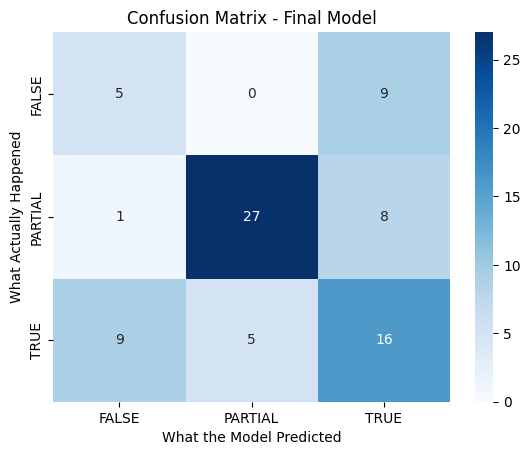

In [48]:
cm = confusion_matrix(y_test, y_pred_locked)

sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['FALSE', 'PARTIAL', 'TRUE'],
            yticklabels=['FALSE', 'PARTIAL', 'TRUE'],
            cmap='Blues')
plt.title('Confusion Matrix - Final Model')
plt.ylabel('What Actually Happened')
plt.xlabel('What the Model Predicted')
plt.show()

In [49]:
coef_df = pd.DataFrame({
    'feature':      LOCKED_FEATURES,
    'coef_FALSE':   model_locked.coef_[0].round(3),
    'coef_PARTIAL': model_locked.coef_[1].round(3),
    'coef_TRUE':    model_locked.coef_[2].round(3)
}).sort_values('coef_TRUE', ascending=False)

print(coef_df.to_string(index=False))

                           feature  coef_FALSE  coef_PARTIAL  coef_TRUE
    event_category_Economic_Policy      -0.230        -0.362      0.592
                         vader_pos      -0.067        -0.183      0.250
                 source_name_Times       0.612        -0.747      0.134
                         vader_neg      -0.042        -0.040      0.082
        event_category_Resignation      -0.188         0.160      0.028
              source_name_Guardian       0.316        -0.313     -0.003
       event_category_Legal_Courts      -0.081         0.153     -0.073
                    vader_compound      -0.015         0.115     -0.100
            event_category_Scandal      -0.160         0.273     -0.112
              source_name_Sky News       0.196        -0.067     -0.129
event_category_Election_Leadership       0.501        -0.367     -0.134
               source_name_Reuters      -0.710         0.931     -0.220
    event_category_Vote_Confidence       0.073         0.205    

---
## Saving the Model So It Can Be Used Later

Right now, the trained model only exists while this notebook is open — close it, and
it's gone. To actually use it somewhere else (like a dashboard), we save it to files.

In [50]:
import joblib

joblib.dump(model_locked, 'credibility_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(LOCKED_FEATURES, 'locked_features.pkl')
joblib.dump(list(X.columns), 'all_feature_columns.pkl')

print("Saved 4 files:")
print(" - credibility_model.pkl     (the trained model)")
print(" - scaler.pkl                (needed to scale new articles the same way)")
print(" - locked_features.pkl       (which 15 clues the model actually uses)")
print(" - all_feature_columns.pkl   (the full 16-column layout, needed to build a new row)")

Saved 4 files:
 - credibility_model.pkl     (the trained model)
 - scaler.pkl                (needed to scale new articles the same way)
 - locked_features.pkl       (which 15 clues the model actually uses)
 - all_feature_columns.pkl   (the full 16-column layout, needed to build a new row)


---
## Trying the Model on a Brand-New Article

This is the real test: an article that was never part of our dataset at all.
We turn it into the same 16 clues the model was trained on, scale it the same way,
keep only the 15 locked clues, and ask the model to predict.

In [51]:
def predict_new_article(source_name, event_category, resolution_hours, headline_text):
    # Step 1: score the headline the same way we did during training
    vs = analyzer.polarity_scores(headline_text)

    # Step 2: build one row with all 16 raw clues, in the exact same layout as training
    row = {col: 0 for col in X.columns}
    row['resolution_time_hours'] = resolution_hours
    row['vader_compound'] = vs['compound']
    row['vader_pos'] = vs['pos']
    row['vader_neg'] = vs['neg']
    row[f'source_name_{source_name}'] = 1
    row[f'event_category_{event_category}'] = 1

    row_df = pd.DataFrame([row])[X.columns]  # keep the exact same column order

    # Step 3: scale it using the SAME scaler fitted during training
    row_scaled = pd.DataFrame(scaler.transform(row_df), columns=X.columns)

    # Step 4: keep only the 15 locked clues the model actually uses
    row_final = row_scaled[LOCKED_FEATURES]

    # Step 5: ask the model to predict
    label_map = {0: 'FALSE', 1: 'PARTIAL', 2: 'TRUE'}
    prediction = model_locked.predict(row_final)[0]
    probabilities = model_locked.predict_proba(row_final)[0]

    print(f"Prediction: {label_map[prediction]}")
    print(f"  FALSE   : {probabilities[0]:.1%}")
    print(f"  PARTIAL : {probabilities[1]:.1%}")
    print(f"  TRUE    : {probabilities[2]:.1%}")

In [52]:
# Example: a brand-new BBC article about a Resignation, never seen by the model before
predict_new_article(
    source_name='BBC',
    event_category='Resignation',
    resolution_hours=3,
    headline_text='Minister faces mounting pressure to resign after leaked messages'
)

Prediction: PARTIAL
  FALSE   : 0.0%
  PARTIAL : 99.5%
  TRUE    : 0.5%
